In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn imblearn joblib

### Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             classification_report, confusion_matrix, ConfusionMatrixDisplay, 
                             roc_auc_score, RocCurveDisplay)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

### Global Configuration & Hyperparameters

In [2]:
# --- File Paths & Names ---
TRAIN_DATA_PATH = 'Train_Dataset.csv'
MASTER_LOG_PATH = 'master_experiment_log.csv'

# --- Dataset Schema ---
TARGET_COL = 'Default'
ID_COL = 'ID'

# --- Preprocessing & Splitting ---
VAL_TEST_SIZE = 0.2
RANDOM_SEED = 42
APPLY_SMOTE = True

# --- Model Configurations ---
RF_CLASS_WEIGHT = None 

RF_N_JOBS = -1

# --- Feature Selection Threshold ---
FEATURE_NOISE_THRESHOLD = 0.005 

# --- Tuning Grid ---
PARAM_GRID = [
    {
        # Grid 1: Bootstrapping is ON (max_samples is allowed)
        'n_estimators': [100, 250, 500, 750, 1000],
        'criterion': ['gini', 'entropy'],
        'max_depth': [20, 25, 30, 40, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5, 10],
        'max_features': ['sqrt', 'log2', 0.2, 0.3],
        'bootstrap': [True],
        'max_samples': [None, 0.7, 0.85] 
    },
    {
        # Grid 2: Bootstrapping is OFF (max_samples is removed to prevent errors)
        'n_estimators': [100, 250, 500, 750, 1000],
        'criterion': ['gini', 'entropy'],
        'max_depth': [20, 25, 30, 40, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5, 10],
        'max_features': ['sqrt', 'log2', 0.2, 0.3],
        'bootstrap': [False]
    }
]

N_ITER = 100

### Load Dataset

In [3]:
print("--- Loading dataset ---")
train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)

--- Loading dataset ---


In [4]:
pd.set_option('display.expand_frame_repr', False)

def enhanced_info(df):
    summary = None
    print(f"Shape: {df.shape}")
    print("\nColumns summary:\n")
    
    summary = df.dtypes.to_frame(name='Dtype')
    summary['Non-Null Count'] = df.notnull().sum()
    summary['Null Count'] = df.isnull().sum()
    summary['Completeness (%)'] = (df.notnull().mean() * 100).round(2)
    
    # Add column numbering
    summary.reset_index(inplace=True)
    summary.rename(columns={'index': 'Column'}, inplace=True)
    
    print(summary)
    
    print("\nMemory usage:", df.memory_usage(deep=True).sum(), "bytes")

enhanced_info(train_df)

Shape: (121856, 40)

Columns summary:

                        Column    Dtype  Non-Null Count  Null Count  Completeness (%)
0                           ID    int64          121856           0            100.00
1                Client_Income      str          118249        3607             97.04
2                    Car_Owned  float64          118275        3581             97.06
3                   Bike_Owned  float64          118232        3624             97.03
4                  Active_Loan  float64          118221        3635             97.02
5                    House_Own  float64          118195        3661             97.00
6                  Child_Count  float64          118218        3638             97.01
7                Credit_Amount      str          118224        3632             97.02
8                 Loan_Annuity      str          117044        4812             96.05
9             Accompany_Client      str          120110        1746             98.57
10          Cli

In [5]:
# Drop ID column immediately to prevent data leakage
if ID_COL in train_df.columns:
    train_df = train_df.drop([ID_COL], axis=1)

print(f"Train dataset shape: {train_df.shape}")

Train dataset shape: (121856, 39)


In [6]:
print("--- Fisher-Pearson Skewness Coefficients ---\n")

# 1. Filter the dataset to only include numeric columns
numeric_data = train_df.select_dtypes(include=['number'])

# 2. Calculate the Fisher-Pearson coefficient of skewness
skewness_scores = numeric_data.skew()

# 3. Sort the scores in descending order to find the most heavily skewed features
skewness_scores_sorted = skewness_scores.sort_values(ascending=False)

# 4. Display the results with a quick reference guide
print("Reference Guide:")
print(" • Normal: -0.5 to +0.5")
print(" • Moderate Skew: ±0.5 to ±1.0")
print(" • Highly Skewed: > +1.0 or < -1.0\n")

print(skewness_scores_sorted)

--- Fisher-Pearson Skewness Coefficients ---

Reference Guide:
 • Normal: -0.5 to +0.5
 • Moderate Skew: ±0.5 to ±1.0
 • Highly Skewed: > +1.0 or < -1.0

Score_Source_2              125.345758
Default                       3.076618
Own_House_Age                 2.724026
Social_Circle_Default         2.656499
Child_Count                   2.191615
Homephone_Tag                 1.496126
Credit_Bureau                 1.259319
Client_Family_Members         1.033818
Workphone_Working             0.973350
Phone_Change                  0.716540
Bike_Owned                    0.712235
Car_Owned                     0.662148
Cleint_City_Rating            0.055199
Application_Process_Day       0.007728
Active_Loan                   0.003299
Application_Process_Hour     -0.034236
Score_Source_1               -0.067090
House_Own                    -0.832083
Mobile_Tag                 -349.078788
dtype: float64


### Clean Data Types

In [7]:
print("--- Cleaning text from numeric columns ---")

# Including all continuous variables that were hiding as strings
cols_to_clean = [
    'Client_Income', 'Credit_Amount', 'Loan_Annuity', 
    'Population_Region_Relative', 'Age_Days', 'Employed_Days', 
    'Registration_Days', 'ID_Days', 'Score_Source_3'
]

def clean_numeric_cols(df, cols):
    for col in cols:
        if col in df.columns:
            # The regex [^\d.-] keeps digits, decimals, and negative signs
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^\d.-]', '', regex=True), errors='coerce')
    return df

train_df = clean_numeric_cols(train_df, cols_to_clean)

--- Cleaning text from numeric columns ---


### Separate Features and Target

In [8]:
X = train_df.drop([TARGET_COL], axis=1)
y = train_df[TARGET_COL]

### Train / Validation Split

In [9]:
print("--- Splitting data into Train and Validation sets ---")
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=VAL_TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

--- Splitting data into Train and Validation sets ---


### Handle Missing Values & Encoding

In [10]:
print("--- Imputing missing values and encoding categories ---")
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X_train.select_dtypes(include=['object', 'str']).columns

# --- Safety Net ---
for col in numeric_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_val[col] = pd.to_numeric(X_val[col], errors='coerce')

# --- Impute Numeric (Median for skewed financial data) ---
num_imputer = SimpleImputer(strategy='median')
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = num_imputer.transform(X_val[numeric_cols])

# --- Impute Categorical ---
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_val[categorical_cols] = cat_imputer.transform(X_val[categorical_cols])

# --- Ordinal Encoding ---
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[categorical_cols] = oe.fit_transform(X_train[categorical_cols].astype(str))
X_val[categorical_cols] = oe.transform(X_val[categorical_cols].astype(str))

# Train data set summary 
enhanced_info(X_train)

--- Imputing missing values and encoding categories ---
Shape: (97484, 38)

Columns summary:

                        Column    Dtype  Non-Null Count  Null Count  Completeness (%)
0                Client_Income  float64           97484           0             100.0
1                    Car_Owned  float64           97484           0             100.0
2                   Bike_Owned  float64           97484           0             100.0
3                  Active_Loan  float64           97484           0             100.0
4                    House_Own  float64           97484           0             100.0
5                  Child_Count  float64           97484           0             100.0
6                Credit_Amount  float64           97484           0             100.0
7                 Loan_Annuity  float64           97484           0             100.0
8             Accompany_Client  float64           97484           0             100.0
9           Client_Income_Type  float64       

### Feature Scaling

In [11]:
print("--- Applying StandardScaler to numeric features ---")
scaler = StandardScaler()

# Fit on training data, transform both
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])

--- Applying StandardScaler to numeric features ---


### Baseline Model for Feature Selection

In [12]:
print("--- Training Baseline Model to calculate Feature Importances ---")

# Train a quick baseline model to see which features actually matter
baseline_rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=RANDOM_SEED, 
    n_jobs=RF_N_JOBS,
    verbose=1
)
baseline_rf.fit(X_train, y_train)

# Create a DataFrame of feature importances
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': baseline_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

--- Training Baseline Model to calculate Feature Importances ---


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.8s finished


### Drop Noise & Create Lean Dataset

--- Visualizing Feature Importances ---


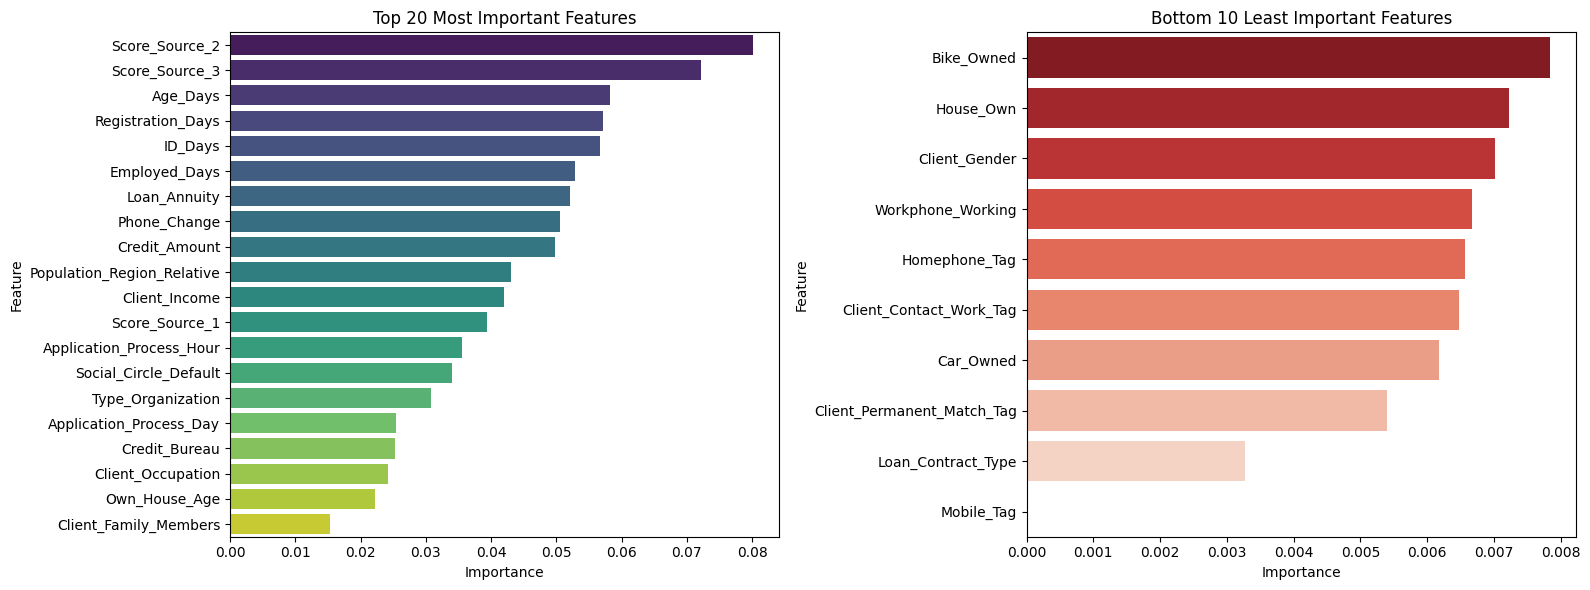


Dropping 2 features with importance < 0.005:
['Loan_Contract_Type', 'Mobile_Tag']


In [13]:
print("--- Visualizing Feature Importances ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 Features
sns.barplot(
    x='Importance', y='Feature', data=feature_importance_df.head(20), 
    ax=axes[0], palette='viridis', hue='Feature', legend=False
)
axes[0].set_title('Top 20 Most Important Features')

# Bottom 10 Features
sns.barplot(
    x='Importance', y='Feature', data=feature_importance_df.tail(10), 
    ax=axes[1], palette='Reds_r', hue='Feature', legend=False
)
axes[1].set_title('Bottom 10 Least Important Features')
plt.tight_layout()
plt.show()

# --- Drop features below threshold ---
features_to_drop = feature_importance_df[feature_importance_df['Importance'] < FEATURE_NOISE_THRESHOLD]['Feature'].tolist()

print(f"\nDropping {len(features_to_drop)} features with importance < {FEATURE_NOISE_THRESHOLD}:")
print(features_to_drop)

X_train_lean = X_train.drop(columns=features_to_drop)
X_val_lean = X_val.drop(columns=features_to_drop)

### Apply SMOTE to the Lean Training Data

In [14]:
if APPLY_SMOTE and RF_CLASS_WEIGHT == None:
    print("--- Applying SMOTE to balance the training data ---")
    smote = SMOTE(random_state=RANDOM_SEED)
    # We apply SMOTE *only* to the training data to prevent leakage!
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_lean, y_train)
    print(f"Original training shape: {X_train_lean.shape}")
    print(f"Resampled training shape: {X_train_resampled.shape}")
else:
    print("Skipping SMOTE.")
    X_train_resampled, y_train_resampled = X_train_lean, y_train

--- Applying SMOTE to balance the training data ---
Original training shape: (97484, 36)
Resampled training shape: (179216, 36)


### Advanced Hyperparameter Tuning

In [13]:
print("\n--- Starting Advanced Hyperparameter Tuning ---")

rf_base = RandomForestClassifier(
    random_state=RANDOM_SEED,
    class_weight=RF_CLASS_WEIGHT,
    verbose=2
)

random_search = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=PARAM_GRID, 
    n_iter=N_ITER,             
    scoring='f1',          
    cv=3,                  
    random_state=RANDOM_SEED,
    n_jobs=RF_N_JOBS
)

random_search.fit(X_train_resampled, y_train_resampled)
best_rf_model = random_search.best_estimator_

print("\n--- Tuning Complete! ---")
print("🏆 Best Parameters Found:")
for param, value in random_search.best_params_.items():
    print(f"  - {param}: {value}")

# Save the model
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f'rf_tuned_{timestamp}.joblib'
joblib.dump(best_rf_model, model_filename)
print(f"\nOptimized model saved as: {model_filename}")


--- Starting Advanced Hyperparameter Tuning ---


/opt/anaconda3/envs/ml_assignment/lib/python3.11/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 1 is smaller than n_iter=2. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   14.4s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   14.8s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   14.9s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:  1.0min
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:  1.0min
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:  1.0min
[Parallel(n_jobs=1)]: Done 364 tasks      | elapsed:  2.4min
[Parallel(n_jobs=1)]: Done 364 tasks      | elapsed:  2.4min
[Parallel(n_jobs=1)]: Done 364 tasks      | elapsed:  2.4min
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:  4.3min
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:  4.3min
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:  4.4min


building tree 1 of 750
building tree 2 of 750
building tree 3 of 750
building tree 4 of 750
building tree 5 of 750
building tree 6 of 750
building tree 7 of 750
building tree 8 of 750
building tree 9 of 750
building tree 10 of 750
building tree 11 of 750
building tree 12 of 750
building tree 13 of 750
building tree 14 of 750
building tree 15 of 750
building tree 16 of 750
building tree 17 of 750
building tree 18 of 750
building tree 19 of 750
building tree 20 of 750
building tree 21 of 750
building tree 22 of 750
building tree 23 of 750
building tree 24 of 750
building tree 25 of 750
building tree 26 of 750
building tree 27 of 750
building tree 28 of 750
building tree 29 of 750
building tree 30 of 750
building tree 31 of 750
building tree 32 of 750
building tree 33 of 750
building tree 34 of 750
building tree 35 of 750
building tree 36 of 750
building tree 37 of 750
building tree 38 of 750
building tree 39 of 750
building tree 40 of 750
building tree 41 of 750
building tree 42 of 750
b

[Parallel(n_jobs=1)]: Done 750 out of 750 | elapsed:  5.0min finished
[Parallel(n_jobs=1)]: Done 750 out of 750 | elapsed:  5.0min finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 364 tasks      | elapsed:    2.1s
[Parallel(n_jobs=1)]: Done 364 tasks      | elapsed:    2.1s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    3.6s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    3.7s
[Parallel(n_jobs=1)]: Done 750 out of 750 | elapsed:    4.2s finished
[Parallel(n_jobs=1)]: Done 750 out of 750 | elapsed:    4.2s finished
[Parallel(n_jobs=1)]: Done 750 out of 750 | elapsed:  5.1min finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 364 tasks    

building tree 1 of 750
building tree 2 of 750
building tree 3 of 750
building tree 4 of 750
building tree 5 of 750
building tree 6 of 750
building tree 7 of 750
building tree 8 of 750
building tree 9 of 750
building tree 10 of 750
building tree 11 of 750
building tree 12 of 750
building tree 13 of 750
building tree 14 of 750
building tree 15 of 750
building tree 16 of 750
building tree 17 of 750
building tree 18 of 750
building tree 19 of 750
building tree 20 of 750
building tree 21 of 750
building tree 22 of 750
building tree 23 of 750
building tree 24 of 750
building tree 25 of 750
building tree 26 of 750
building tree 27 of 750
building tree 28 of 750
building tree 29 of 750
building tree 30 of 750
building tree 31 of 750
building tree 32 of 750
building tree 33 of 750
building tree 34 of 750
building tree 35 of 750
building tree 36 of 750
building tree 37 of 750
building tree 38 of 750
building tree 39 of 750
building tree 40 of 750


...

[Parallel(n_jobs=1)]: Done 364 tasks      | elapsed:  3.3min


building tree 365 of 750
building tree 366 of 750
building tree 367 of 750
building tree 368 of 750
building tree 369 of 750
building tree 370 of 750
building tree 371 of 750
building tree 372 of 750
building tree 373 of 750
building tree 374 of 750
building tree 375 of 750
building tree 376 of 750
building tree 377 of 750
building tree 378 of 750
building tree 379 of 750
building tree 380 of 750
building tree 381 of 750
building tree 382 of 750
building tree 383 of 750
building tree 384 of 750
building tree 385 of 750
building tree 386 of 750
building tree 387 of 750
building tree 388 of 750
building tree 389 of 750
building tree 390 of 750
building tree 391 of 750
building tree 392 of 750
building tree 393 of 750
building tree 394 of 750
building tree 395 of 750
building tree 396 of 750
building tree 397 of 750
building tree 398 of 750
building tree 399 of 750
building tree 400 of 750
building tree 401 of 750
building tree 402 of 750
building tree 403 of 750
building tree 404 of 750


[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:  7.4min


building tree 648 of 750
building tree 649 of 750
building tree 650 of 750
building tree 651 of 750
building tree 652 of 750
building tree 653 of 750
building tree 654 of 750
building tree 655 of 750
building tree 656 of 750
building tree 657 of 750
building tree 658 of 750
building tree 659 of 750
building tree 660 of 750
building tree 661 of 750
building tree 662 of 750
building tree 663 of 750
building tree 664 of 750
building tree 665 of 750
building tree 666 of 750
building tree 667 of 750
building tree 668 of 750
building tree 669 of 750
building tree 670 of 750
building tree 671 of 750
building tree 672 of 750
building tree 673 of 750
building tree 674 of 750
building tree 675 of 750
building tree 676 of 750
building tree 677 of 750
building tree 678 of 750
building tree 679 of 750
building tree 680 of 750
building tree 681 of 750
building tree 682 of 750
building tree 683 of 750
building tree 684 of 750
building tree 685 of 750
building tree 686 of 750
building tree 687 of 750


[Parallel(n_jobs=1)]: Done 750 out of 750 | elapsed:  8.3min finished


### Finding the Optimal Probability Threshold

In [14]:
print("--- Searching for Optimal Probability Threshold ---")

# Predict probabilities on the untouched VALIDATION set
y_val_probs = best_rf_model.predict_proba(X_val_lean)[:, 1]

# thresholds = np.arange(0.10, 0.95, 0.05)
thresholds = np.arange(0.15, 0.60, 0.01)
best_threshold = 0.5
best_f1 = 0

print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 48)

for thresh in thresholds:
    y_val_pred_custom = (y_val_probs >= thresh).astype(int)
    
    prec = precision_score(y_val, y_val_pred_custom, zero_division=0)
    rec = recall_score(y_val, y_val_pred_custom)
    f1 = f1_score(y_val, y_val_pred_custom)
    
    print(f"{thresh:.2f}       | {prec:.4f}     | {rec:.4f}     | {f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print("-" * 48)
print(f"🏆 Best Threshold for F1: {best_threshold:.2f} (Max F1: {best_f1:.4f})")

# Generate our final validation predictions using this optimal threshold
y_val_pred_final = (y_val_probs >= best_threshold).astype(int)

--- Searching for Optimal Probability Threshold ---


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 364 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    1.7s
[Parallel(n_jobs=1)]: Done 750 out of 750 | elapsed:    1.9s finished


Threshold  | Precision  | Recall     | F1-Score  
------------------------------------------------
0.15       | 0.1276     | 0.8146     | 0.2207
0.16       | 0.1327     | 0.7877     | 0.2271
0.17       | 0.1386     | 0.7628     | 0.2346
0.18       | 0.1447     | 0.7390     | 0.2420
0.19       | 0.1509     | 0.7059     | 0.2487
0.20       | 0.1585     | 0.6831     | 0.2572
0.21       | 0.1639     | 0.6506     | 0.2619
0.22       | 0.1717     | 0.6247     | 0.2694
0.23       | 0.1774     | 0.5896     | 0.2728
0.24       | 0.1861     | 0.5663     | 0.2802
0.25       | 0.1931     | 0.5353     | 0.2839
0.26       | 0.1998     | 0.5053     | 0.2863
0.27       | 0.2089     | 0.4799     | 0.2911
0.28       | 0.2176     | 0.4530     | 0.2940
0.29       | 0.2266     | 0.4281     | 0.2963
0.30       | 0.2365     | 0.4043     | 0.2984
0.31       | 0.2444     | 0.3784     | 0.2970
0.32       | 0.2557     | 0.3560     | 0.2976
0.33       | 0.2614     | 0.3266     | 0.2904
0.34       | 0.2717     | 0

### Final Evaluation


--- Final Validation Set Performance ---
Accuracy:  0.8464
Precision: 0.2365
Recall:    0.4043
F1-Score:  0.2984
ROC AUC:   0.7471

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.89      0.91     22403
           1       0.24      0.40      0.30      1969

    accuracy                           0.85     24372
   macro avg       0.59      0.64      0.61     24372
weighted avg       0.89      0.85      0.86     24372



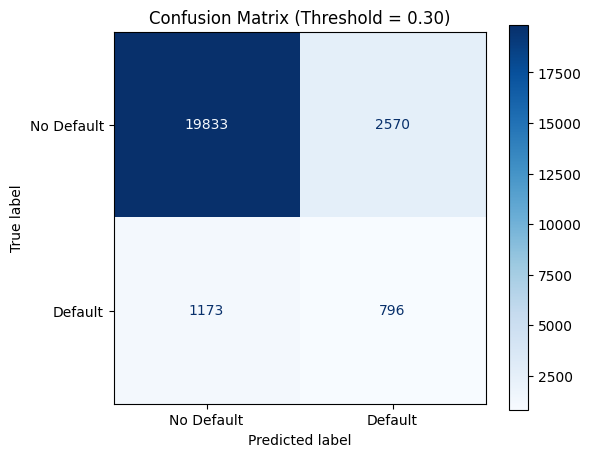

In [15]:
print("\n--- Final Validation Set Performance ---")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred_final):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_final):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred_final):.4f}")
print(f"F1-Score:  {f1_score(y_val, y_val_pred_final):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_val, y_val_probs):.4f}")

print("\nClassification Report:\n", classification_report(y_val, y_val_pred_final))

cm = confusion_matrix(y_val, y_val_pred_final)
tn, fp, fn, tp = cm.ravel()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"No {TARGET_COL}", TARGET_COL])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title(f"Confusion Matrix (Threshold = {best_threshold:.2f})")
plt.show()

### ROC Curve

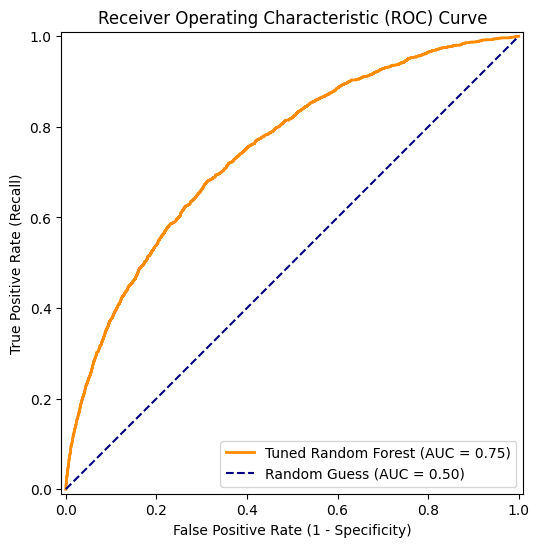

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

roc_disp = RocCurveDisplay.from_predictions(
    y_val, 
    y_val_probs, 
    name=f"Tuned Random Forest",
    ax=ax,
    curve_kwargs={"color": "darkorange", "linewidth": 2}
)

ax.plot([0, 1], [0, 1], color="navy", linestyle="--", label="Random Guess (AUC = 0.50)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.legend(loc="lower right")
plt.show()

### Master Experiment Log

In [17]:
print("--- Saving Optimized Predictions and Logs ---")

# Extract the parameters safely
best_n_est = getattr(best_rf_model, 'n_estimators', None)
best_criterion = getattr(best_rf_model, 'criterion', None)           # NEW
best_depth = getattr(best_rf_model, 'max_depth', None)
best_min_split = getattr(best_rf_model, 'min_samples_split', None)   # NEW
best_min_leaf = getattr(best_rf_model, 'min_samples_leaf', None)
best_max_feat = getattr(best_rf_model, 'max_features', None)
best_bootstrap = getattr(best_rf_model, 'bootstrap', None)           # NEW
best_max_samples = getattr(best_rf_model, 'max_samples', None)       # NEW

# Create a dictionary of the current run's data using ONLY your existing columns
data = {
    'Timestamp': timestamp,
    'Algorithm': 'Random Forest (Expanded Grid)',
    'feat. noice thresh.': FEATURE_NOISE_THRESHOLD,
    
    # Hyperparameters
    'n_estimators': best_n_est,
    'criterion': best_criterion,
    'max_depth': best_depth,
    'min_samples_split': best_min_split,
    'min_samples_leaf': best_min_leaf,
    'max_features': best_max_feat,
    'bootstrap': best_bootstrap,
    'max_samples': best_max_samples,
    
    # Global Configs
    'SMOTE': APPLY_SMOTE and RF_CLASS_WEIGHT == None,
    'Class Weight': RF_CLASS_WEIGHT,
    'Opt_Threshold': f"{best_threshold:.2f}",
    
    # Metrics
    'Accuracy': f"{accuracy_score(y_val, y_val_pred_final):.4f}",
    'Precision': f"{precision_score(y_val, y_val_pred_final):.4f}",
    'Recall': f"{recall_score(y_val, y_val_pred_final):.4f}",
    'F1_Score': f"{f1_score(y_val, y_val_pred_final):.4f}",
    'ROC_AUC': f"{roc_auc_score(y_val, y_val_probs):.4f}",
    
    # Confusion Matrix
    'TN': tn,
    'FP': fp,
    'FN': fn,
    'TP': tp
}

# Convert the current run into a 1-row DataFrame
new_row_df = pd.DataFrame([data])

# Append to the existing CSV safely
if os.path.isfile(MASTER_LOG_PATH):
    # Read the old log
    old_log_df = pd.read_csv(MASTER_LOG_PATH)
    
    # pd.concat automatically aligns columns exactly by their name. 
    updated_log_df = pd.concat([old_log_df, new_row_df], ignore_index=True)
    
    # Overwrite the file with the perfectly aligned data
    updated_log_df.to_csv(MASTER_LOG_PATH, index=False)
else:
    # If the file doesn't exist yet, save the new row as the first entry
    new_row_df.to_csv(MASTER_LOG_PATH, index=False)

print(f"Metrics and hyperparameters safely aligned and appended to: {MASTER_LOG_PATH}")

--- Saving Optimized Predictions and Logs ---
Metrics and hyperparameters safely aligned and appended to: master_experiment_log.csv
